In [15]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [16]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [18]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [19]:
df.drop(['deck'], axis=1, inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


survived: 0 outliers (Z-score > 3 bounds: -1.08 - 1.84)
pclass: 0 outliers (Z-score > 3 bounds: -0.20 - 4.82)
age: 7 outliers (Z-score > 3 bounds: -9.31 - 68.71)
sibsp: 30 outliers (Z-score > 3 bounds: -2.79 - 3.83)
parch: 15 outliers (Z-score > 3 bounds: -2.04 - 2.80)
fare: 20 outliers (Z-score > 3 bounds: -116.88 - 181.28)


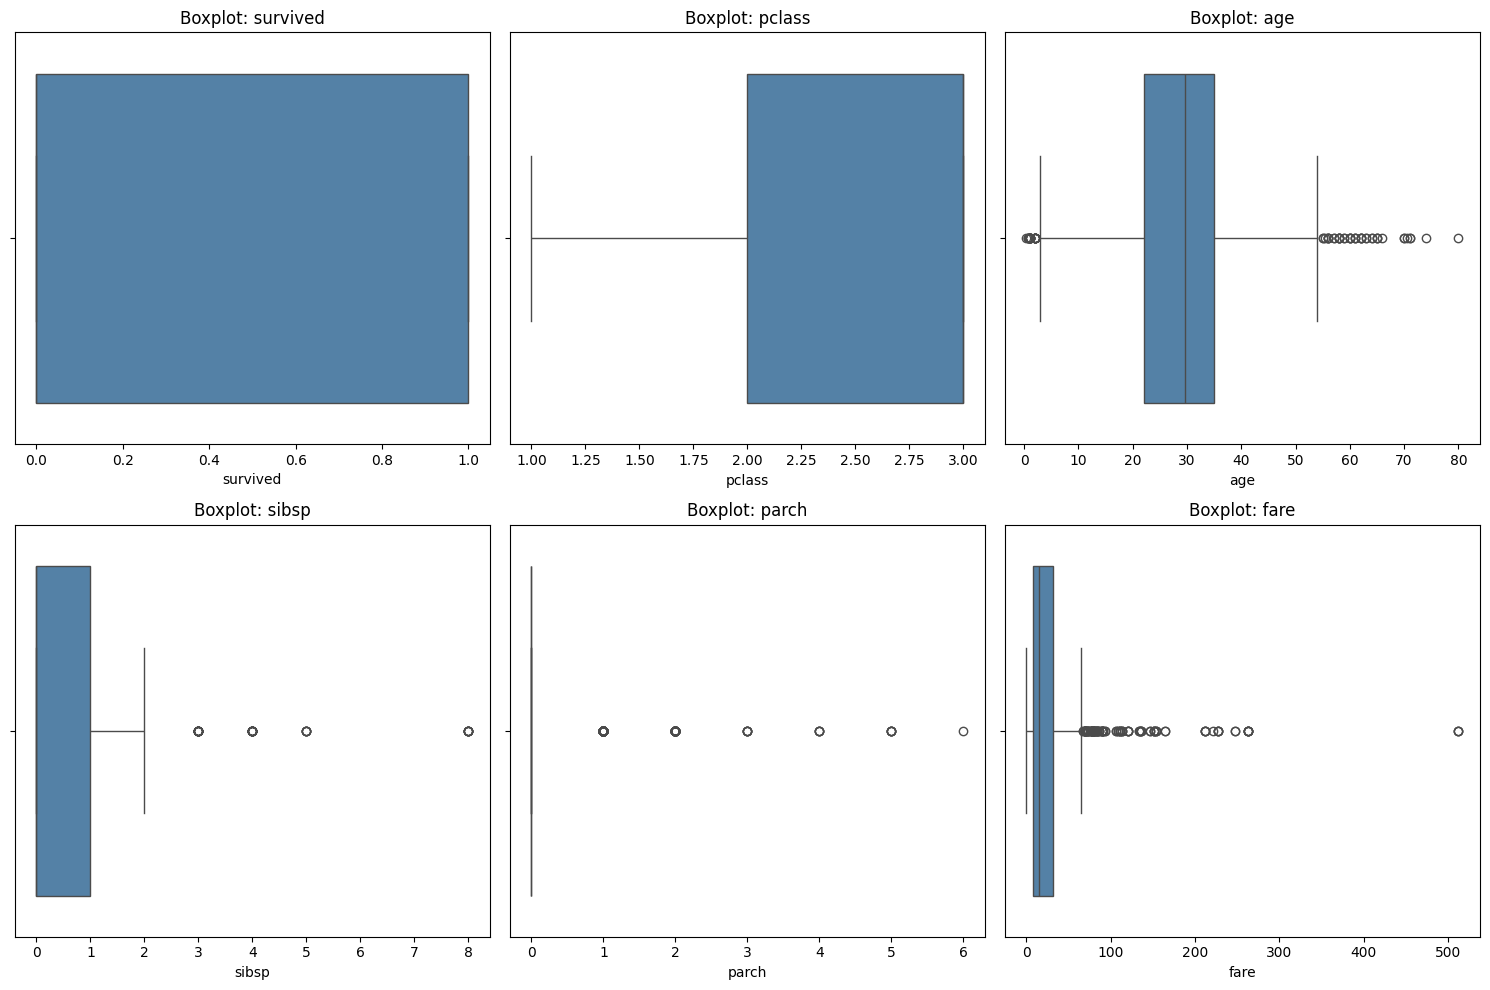

In [21]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
z_outlier_summary = {}

for col in numerical_cols:
    z_scores = stats.zscore(df[col], nan_policy='omit')
    outliers = df[np.abs(z_scores) > 3]
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val
    
    z_outlier_summary[col] = {
        'count': len(outliers),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    print(f"{col}: {len(outliers)} outliers (Z-score > 3 bounds: {lower_bound:.2f} - {upper_bound:.2f})")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Titanic Dataset: Correlation Heatmap of Numerical Features",
    labels=dict(color="Correlation Coefficient")
)

fig.update_layout(
    width=600,
    height=600,
    xaxis_title="",
    yaxis_title=""
)

fig.show()

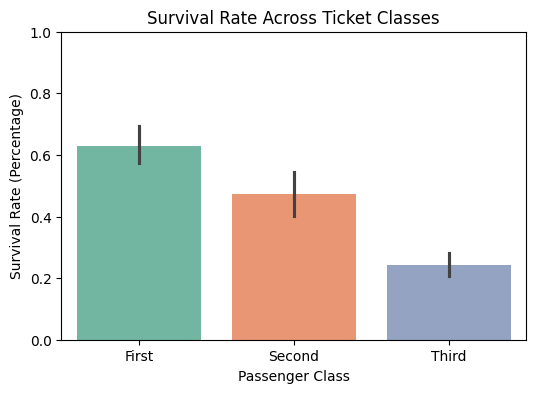

In [28]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='class', y='survived', hue='class', palette='Set2', legend=False)

plt.title('Survival Rate Across Ticket Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (Percentage)')
plt.ylim(0, 1)
plt.show()

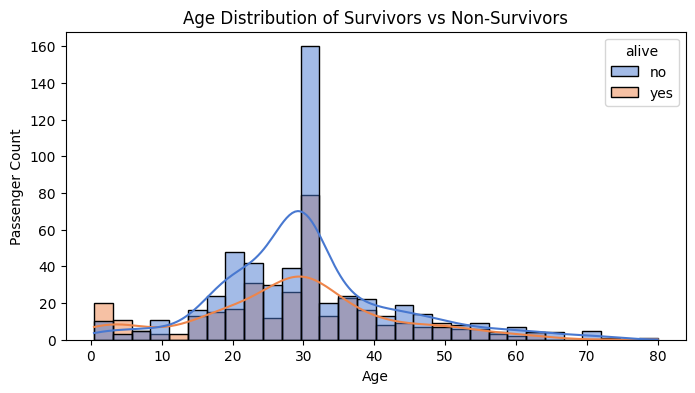

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='alive', kde=True, multiple='layer', palette='muted', bins=30)

plt.title('Age Distribution of Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Passenger Count')
plt.show()

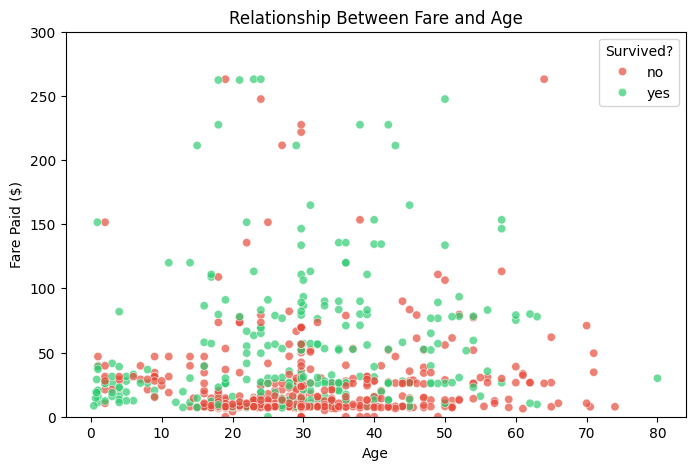

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='fare', hue='alive', alpha=0.7, palette={'yes': '#2ecc71', 'no': '#e74c3c'})

plt.title('Relationship Between Fare and Age')
plt.xlabel('Age')
plt.ylabel('Fare Paid ($)')
plt.ylim(0, 300)
plt.legend(title='Survived?')
plt.show()

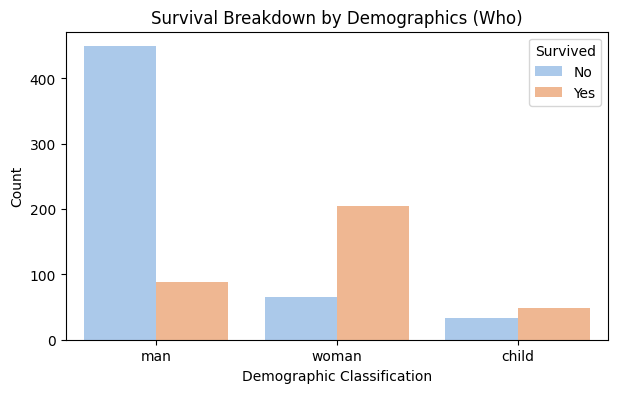

In [32]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='who', hue='survived', palette='pastel')

plt.title('Survival Breakdown by Demographics (Who)')
plt.xlabel('Demographic Classification')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Which feature do you think most affects survival, and why?
Based on the dataset, Sex (Gender) is the single feature that most drastically affects survival, with Pclass (Passenger Class) serving as the second most critical factor.

### Key Insights & Data Story: Titanic Dataset

Our initial exploration of the Titanic dataset reveals a structured shape of **891 rows** and **15 columns** featuring a mix of numerical, categorical, and boolean types. 
While columns like **`age`** and **`embarked`** have been successfully cleaned and fully imputed to 891 non-null values, the **`deck`** column remains highly incomplete with only **203 non-null entries** (~77% missing data).
The `age` column is now properly formatted as a float, allowing it to be represented alongside key metrics like **`fare`**, which is heavily right-skewed with an average of **$32.20** and a maximum of over **$512**. 
Overall, the training subset features a baseline survival rate of **38.4%**, and addressing the sparse `deck` feature remains our primary pre-modeling challenge.